In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv(
    "diabetes_binary_health_indicators_BRFSS2015.csv"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
rows, columns = df.shape

print("Number of rows    :", rows)
print("Number of columns :", columns)

Number of rows    : 253680
Number of columns : 22


In [6]:
print("Features available in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Features available in the dataset:

1. Diabetes_binary
2. HighBP
3. HighChol
4. CholCheck
5. BMI
6. Smoker
7. Stroke
8. HeartDiseaseorAttack
9. PhysActivity
10. Fruits
11. Veggies
12. HvyAlcoholConsump
13. AnyHealthcare
14. NoDocbcCost
15. GenHlth
16. MentHlth
17. PhysHlth
18. DiffWalk
19. Sex
20. Age
21. Education
22. Income


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 24206


In [11]:
target_counts = df["Diabetes_binary"].value_counts()

print("Target class counts:")
print(target_counts)

Target class counts:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


In [12]:
target_percentage = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    * 100
)

print("Target class percentages:")
print(target_percentage)

Target class percentages:
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


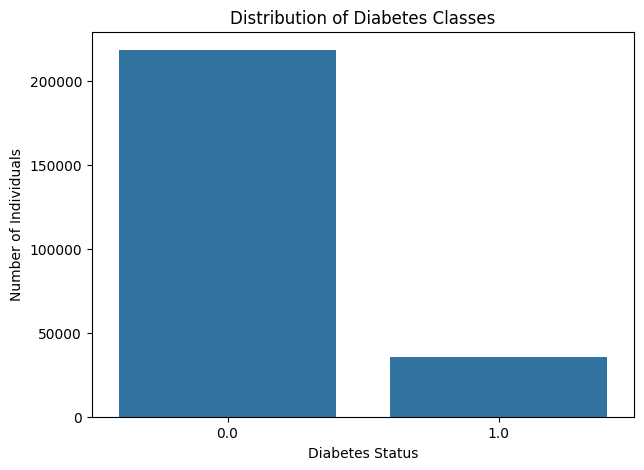

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Diabetes_binary",
    data=df
)

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Individuals")

plt.show()

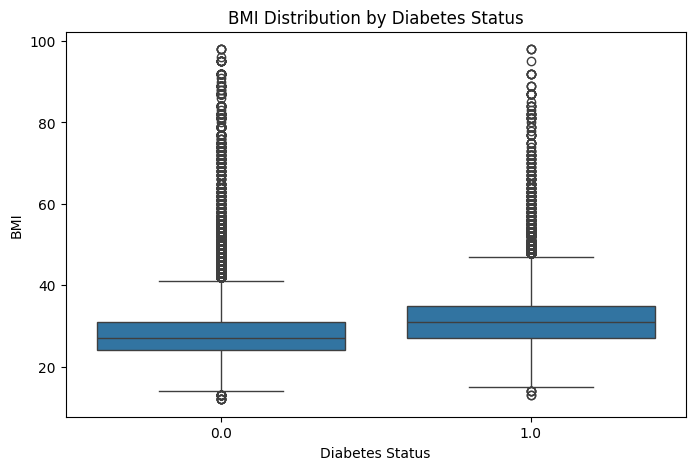

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Diabetes_binary",
    y="BMI",
    data=df
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.show()

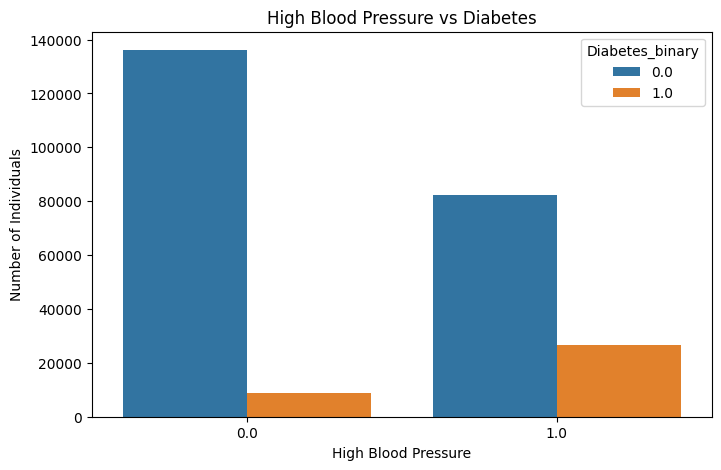

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="HighBP",
    hue="Diabetes_binary",
    data=df
)

plt.title("High Blood Pressure vs Diabetes")
plt.xlabel("High Blood Pressure")
plt.ylabel("Number of Individuals")

plt.show()

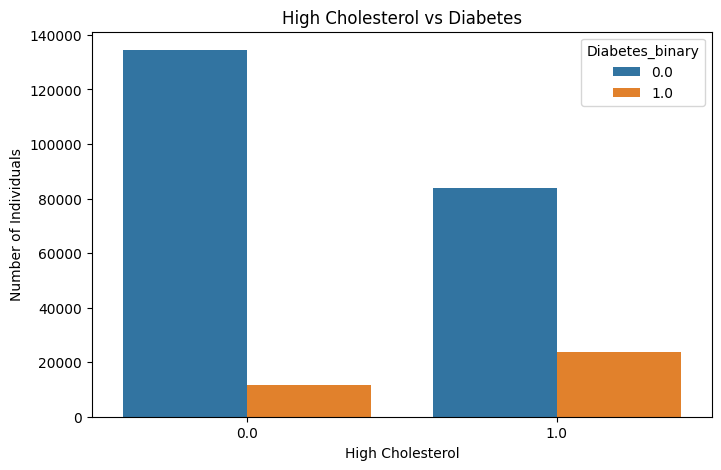

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="HighChol",
    hue="Diabetes_binary",
    data=df
)

plt.title("High Cholesterol vs Diabetes")
plt.xlabel("High Cholesterol")
plt.ylabel("Number of Individuals")

plt.show()

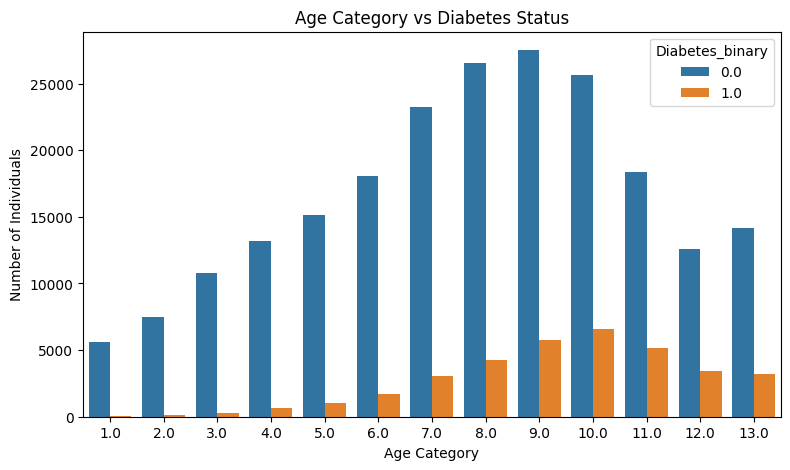

In [17]:
plt.figure(figsize=(9, 5))

sns.countplot(
    x="Age",
    hue="Diabetes_binary",
    data=df
)

plt.title("Age Category vs Diabetes Status")
plt.xlabel("Age Category")
plt.ylabel("Number of Individuals")

plt.show()

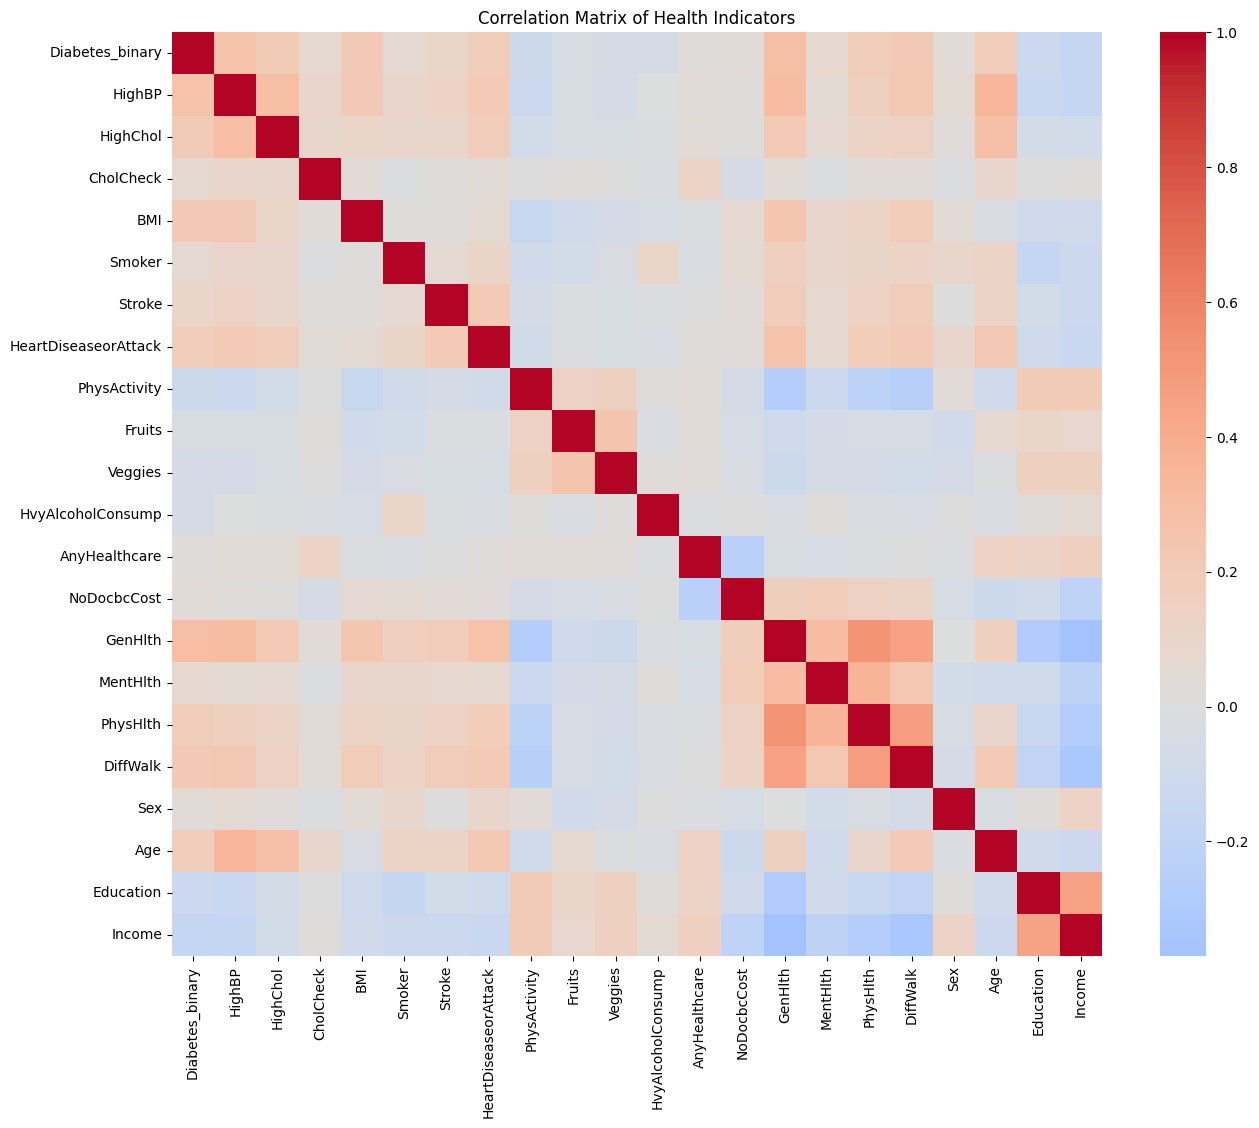

In [19]:
correlation_matrix = df.corr()

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Health Indicators")

plt.show()

In [20]:
X = df.drop("Diabetes_binary", axis=1)

# Separate target variable
y = df["Diabetes_binary"]

print("Feature shape :", X.shape)
print("Target shape  :", y.shape)

Feature shape : (253680, 21)
Target shape  : (253680,)


In [21]:
if "ID" in X.columns:
    X = X.drop("ID", axis=1)

print("Final feature shape:", X.shape)

Final feature shape: (253680, 21)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [27]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM training completed!")

SVM training completed!


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest training completed!")

Random Forest training completed!


In [30]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", negative)
print("Positive samples:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Negative samples: 174595
Positive samples: 28349
Scale Pos Weight: 6.158771032487919


In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost training completed!")

XGBoost training completed!


In [34]:
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\n" + "=" * 45)
    print(name)
    print("=" * 45)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

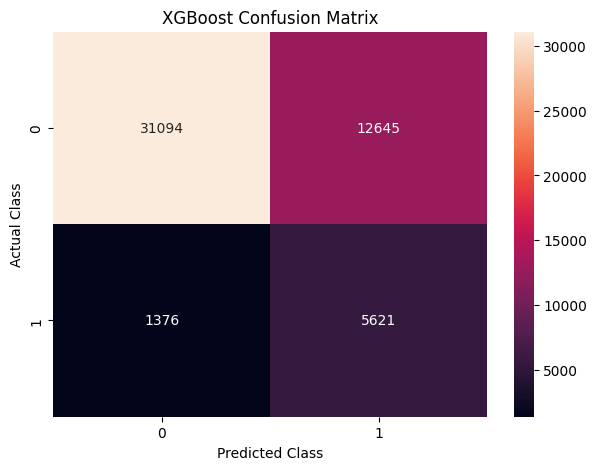

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [40]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", round(roc_auc, 4))

XGBoost ROC-AUC: 0.8356


In [41]:
results = []

models_predictions = {
    "Logistic Regression": y_pred_log,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, predictions in models_predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.731197,0.310398,0.776904,0.443574
1,SVM,0.726585,0.307347,0.783764,0.441546
2,Random Forest,0.856985,0.445974,0.152780,0.227592
3,XGBoost,0.723648,0.307730,0.803344,0.444999


In [42]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print("Top 15 Important Features:")
print(importance.head(15))

Top 15 Important Features:
BMI             0.172916
Age             0.127750
GenHlth         0.105226
Income          0.084718
HighBP          0.076566
PhysHlth        0.070041
Education       0.058692
MentHlth        0.053519
HighChol        0.038035
Fruits          0.028370
Smoker          0.028114
Sex             0.025106
DiffWalk        0.025098
PhysActivity    0.022437
Veggies         0.021853
dtype: float64


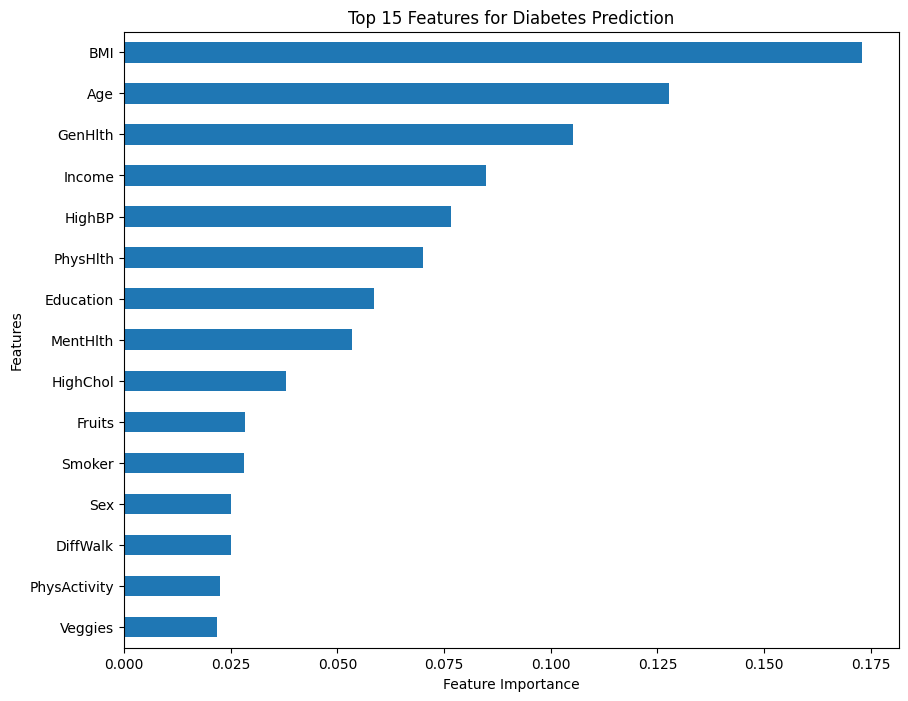

In [43]:
plt.figure(figsize=(10, 8))

importance.head(15).plot(
    kind="barh"
)

plt.title("Top 15 Features for Diabetes Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [44]:
sample_patient = pd.DataFrame(
    [[0] * len(X.columns)],
    columns=X.columns
)

print(sample_patient)

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       0         0          0    0       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0             0       0        0  ...              0            0        0   

   MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income  
0         0         0         0    0    0          0       0  

[1 rows x 21 columns]


In [45]:
sample_scaled = scaler.transform(sample_patient)

prediction = log_model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Diabetes-positive class")
else:
    print("Prediction: Diabetes-negative class")

Prediction: Diabetes-negative class


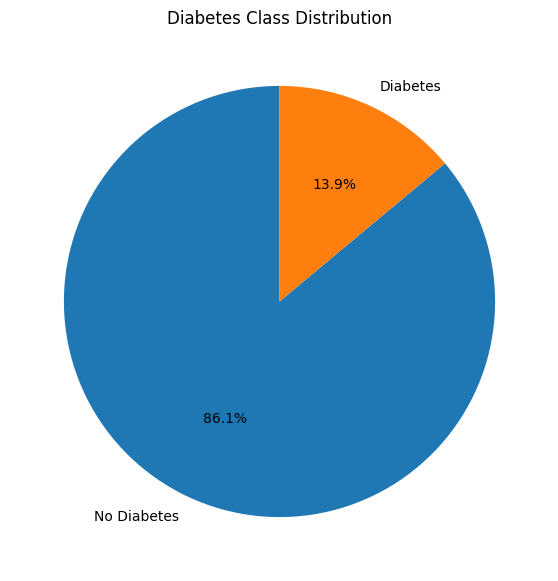

In [46]:
labels = ["No Diabetes", "Diabetes"]

plt.figure(figsize=(7, 7))

plt.pie(
    target_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Diabetes Class Distribution")

plt.show()

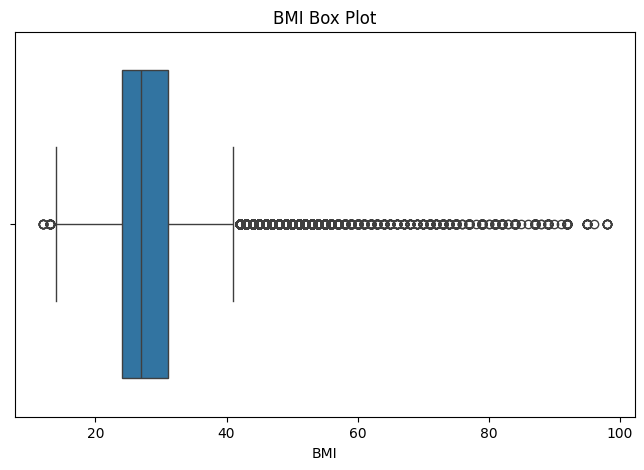

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["BMI"]
)

plt.title("BMI Box Plot")
plt.xlabel("BMI")

plt.show()

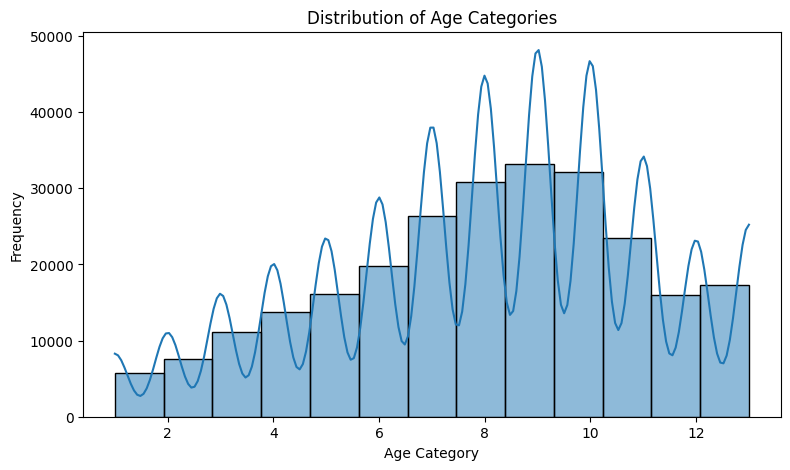

In [48]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=13,
    kde=True
)

plt.title("Distribution of Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Frequency")

plt.show()

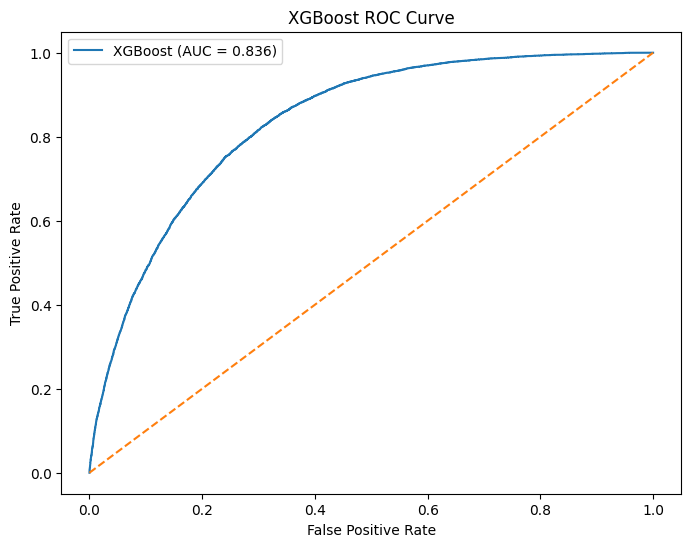

In [51]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

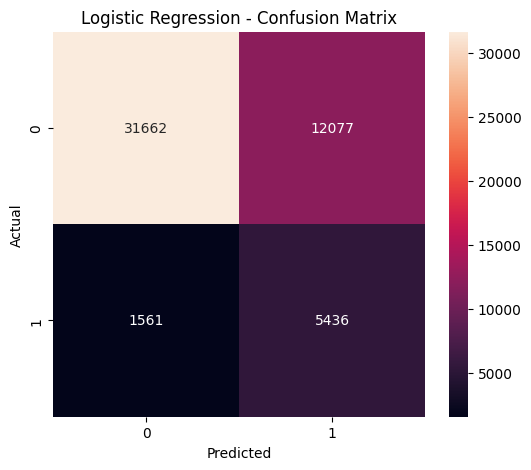

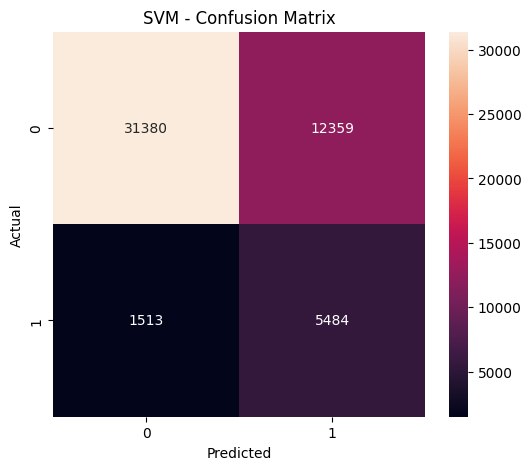

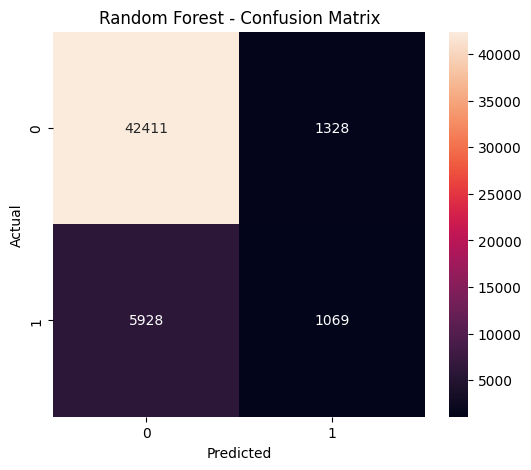

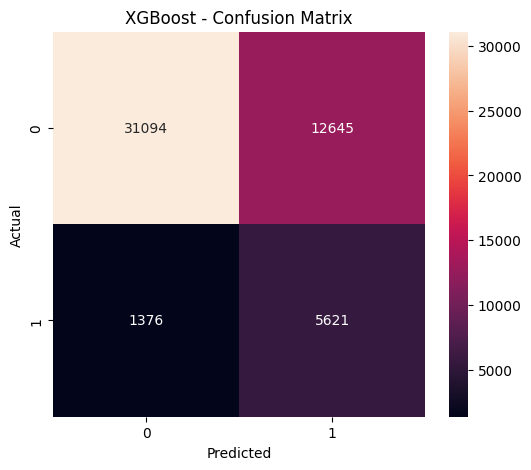

In [52]:
model_data = {
    "Logistic Regression": (
        y_test,
        y_pred_log
    ),

    "SVM": (
        y_test,
        y_pred_svm
    ),

    "Random Forest": (
        y_test,
        y_pred_rf
    ),

    "XGBoost": (
        y_test,
        y_pred_xgb
    )
}

for name, (actual, predicted) in model_data.items():

    cm = confusion_matrix(
        actual,
        predicted
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(
        f"{name} - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [53]:
for column in df.columns:
    print("\n" + "=" * 50)
    print("Feature:", column)
    print("Number of unique values:", df[column].nunique())
    print("Unique values:", df[column].unique()[:20])


Feature: Diabetes_binary
Number of unique values: 2
Unique values: [0. 1.]

Feature: HighBP
Number of unique values: 2
Unique values: [1. 0.]

Feature: HighChol
Number of unique values: 2
Unique values: [1. 0.]

Feature: CholCheck
Number of unique values: 2
Unique values: [1. 0.]

Feature: BMI
Number of unique values: 84
Unique values: [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45.]

Feature: Smoker
Number of unique values: 2
Unique values: [1. 0.]

Feature: Stroke
Number of unique values: 2
Unique values: [0. 1.]

Feature: HeartDiseaseorAttack
Number of unique values: 2
Unique values: [0. 1.]

Feature: PhysActivity
Number of unique values: 2
Unique values: [0. 1.]

Feature: Fruits
Number of unique values: 2
Unique values: [0. 1.]

Feature: Veggies
Number of unique values: 2
Unique values: [1. 0.]

Feature: HvyAlcoholConsump
Number of unique values: 2
Unique values: [0. 1.]

Feature: AnyHealthcare
Number of unique values: 2
Unique values: [1. 0.]

Fe

In [54]:
binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk"
]

for feature in binary_features:

    print("\n", "=" * 45)
    print(feature)

    percentage = (
        df[feature]
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    print(percentage.round(2))


HighBP
HighBP
0.0    57.1
1.0    42.9
Name: proportion, dtype: float64

HighChol
HighChol
0.0    57.59
1.0    42.41
Name: proportion, dtype: float64

CholCheck
CholCheck
0.0     3.73
1.0    96.27
Name: proportion, dtype: float64

Smoker
Smoker
0.0    55.68
1.0    44.32
Name: proportion, dtype: float64

Stroke
Stroke
0.0    95.94
1.0     4.06
Name: proportion, dtype: float64

HeartDiseaseorAttack
HeartDiseaseorAttack
0.0    90.58
1.0     9.42
Name: proportion, dtype: float64

PhysActivity
PhysActivity
0.0    24.35
1.0    75.65
Name: proportion, dtype: float64

Fruits
Fruits
0.0    36.57
1.0    63.43
Name: proportion, dtype: float64

Veggies
Veggies
0.0    18.86
1.0    81.14
Name: proportion, dtype: float64

HvyAlcoholConsump
HvyAlcoholConsump
0.0    94.38
1.0     5.62
Name: proportion, dtype: float64

AnyHealthcare
AnyHealthcare
0.0     4.89
1.0    95.11
Name: proportion, dtype: float64

NoDocbcCost
NoDocbcCost
0.0    91.58
1.0     8.42
Name: proportion, dtype: float64

DiffWalk
DiffWa

In [55]:
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["BMI"] < lower_bound) |
    (df["BMI"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of BMI outliers:", len(outliers))

Q1: 24.0
Q3: 31.0
IQR: 7.0

Lower Bound: 13.5
Upper Bound: 41.5

Number of BMI outliers: 9847


In [57]:
results = []

models_predictions = {
    "Logistic Regression": y_pred_log,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, predictions in models_predictions.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.723648,0.307730,0.803344,0.444999
1,Logistic Regression,0.731197,0.310398,0.776904,0.443574
2,SVM,0.726585,0.307347,0.783764,0.441546
3,Random Forest,0.856985,0.445974,0.152780,0.227592


<Figure size 1200x600 with 0 Axes>

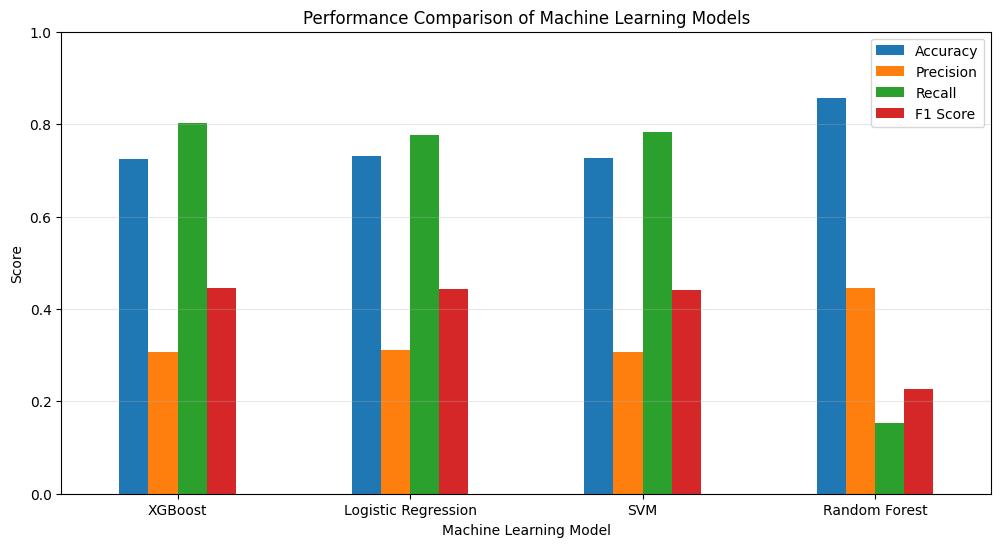

In [58]:
plt.figure(figsize=(12, 6))

results_plot = results_df.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [59]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(), "Model"
]

best_f1_score = results_df["F1 Score"].max()

print("Best Model:", best_model_name)
print("Best F1 Score:", round(best_f1_score, 4))

Best Model: XGBoost
Best F1 Score: 0.445


In [60]:
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Logistic Regression ROC-AUC:", round(log_auc, 4))
print("Random Forest ROC-AUC:", round(rf_auc, 4))
print("XGBoost ROC-AUC:", round(xgb_auc, 4))

Logistic Regression ROC-AUC: 0.8266
Random Forest ROC-AUC: 0.8016
XGBoost ROC-AUC: 0.8356


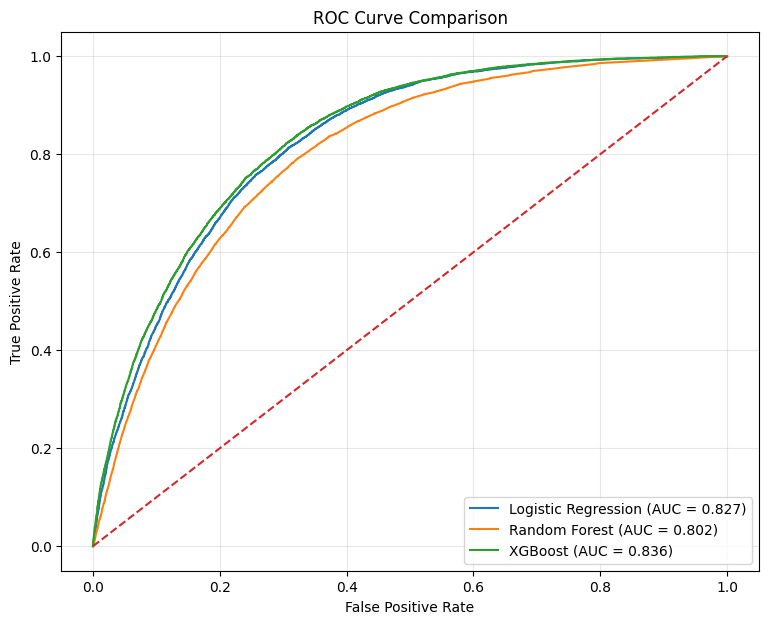

In [61]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(9, 7))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

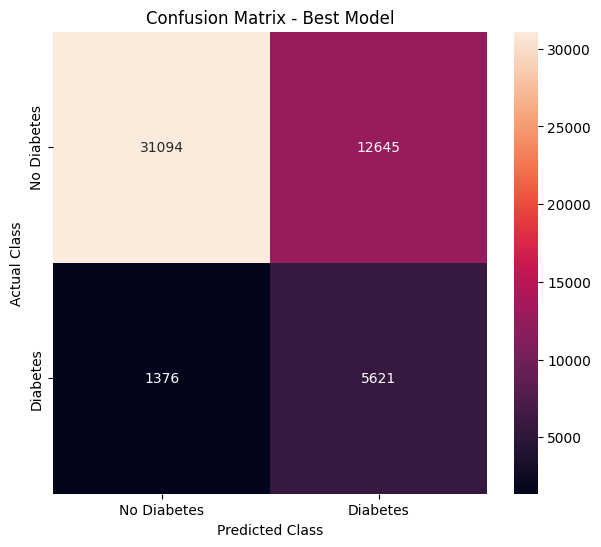

In [62]:
best_predictions = y_pred_xgb

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

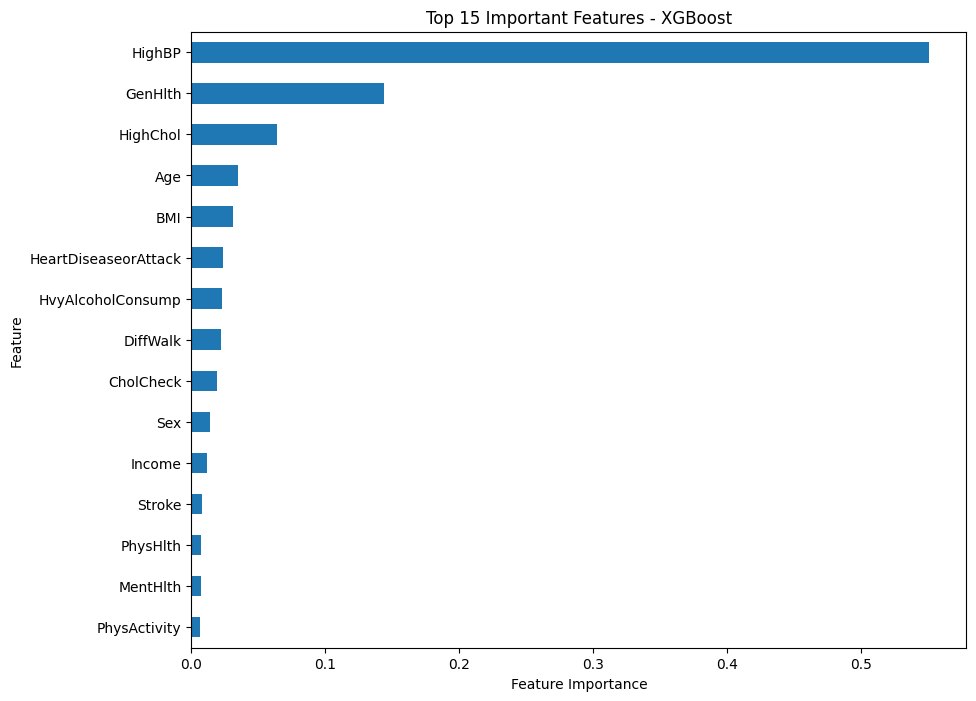

In [65]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))

xgb_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Important Features - XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [66]:
sample_patient = pd.DataFrame({
    "HighBP": [1],
    "HighChol": [1],
    "CholCheck": [1],
    "BMI": [30],
    "Smoker": [0],
    "Stroke": [0],
    "HeartDiseaseorAttack": [0],
    "PhysActivity": [1],
    "Fruits": [1],
    "Veggies": [1],
    "HvyAlcoholConsump": [0],
    "AnyHealthcare": [1],
    "NoDocbcCost": [0],
    "GenHlth": [3],
    "MentHlth": [5],
    "PhysHlth": [5],
    "DiffWalk": [0],
    "Sex": [1],
    "Age": [8],
    "Education": [4],
    "Income": [6]
})

sample_scaled = scaler.transform(sample_patient)

prediction = log_model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Diabetes-positive class")
else:
    print("Prediction: No diabetes class")

Prediction: Diabetes-positive class


In [67]:
probability = log_model.predict_proba(sample_scaled)[0][1]

print("Probability of diabetes-positive class:",
      round(probability * 100, 2), "%")

Probability of diabetes-positive class: 66.07 %


In [68]:
import joblib

joblib.dump(log_model, "diabetes_prediction_model.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [69]:
results_df.to_csv(
    "diabetes_model_comparison.csv",
    index=False
)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


This project developed a machine learning-based system for predicting the diabetes-positive class using health and lifestyle information from the CDC Diabetes Health Indicators dataset.

The dataset was explored through statistical analysis and visualization to understand important patterns and relationships between health indicators and diabetes status.

Data preprocessing included checking missing values, duplicate records, class distribution, feature relationships, and feature scaling where required.

Four classification algorithms were implemented:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest
4. XGBoost

The models were evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

The best-performing model was selected based primarily on F1 Score, while ROC-AUC and other evaluation metrics were also considered.

Feature importance analysis was performed to identify the health and lifestyle variables that contributed most to the model's predictions.

The final model demonstrates how machine learning can be applied to structured health data to identify individuals belonging to the diabetes-positive class. This project is intended for educational and analytical purposes and should not be considered a medical diagnostic system.